In [1]:
# 변수의 shape, type, value 확인
def p(var,_str='') :
    if _str=='\n' or _str=='cr' :
        _str = '\n'
    else :
        print(f'[{_str}]:')
        _str = ''
    if type(var)!=type([]):
        try:
            print(f'Shape:{var.shape}')
        except :
            pass
    print(f'Type: {type(var)}')
    print(f'Values: {var}'+_str)

def pst(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}, {type(_x)}')
def ps(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}')

In [2]:
%%capture
!pip -q install lightning torchinfo

# **실습 1 : VGG Model Fine Tuning**

## **Import Module**

In [3]:
import torch
from torch import nn
from torch.nn import functional as F
from torchmetrics import functional as FM
from torch.utils.data import DataLoader, random_split
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.transforms import v2
from torchinfo import summary

import lightning as L
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 3.5]
plt.rcParams["font.size"] = "8"

device ='cuda:0'
torch.__version__,L.__version__

('2.8.0+cu126', '2.5.5')

## **Dataset**

In [4]:
from torchvision.datasets import CIFAR10

transform = v2.Compose([
    v2.ToImage(),
    v2.Resize((48, 48), antialias=True),
    v2.ToDtype(torch.float32, scale=True) ] )

batch_size = 256
trainset = CIFAR10(root='./CIFAR10', train=True, download=True, transform=transform)
testset = CIFAR10(root='./CIFAR10', train=False, download=True, transform=transform)
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=7)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=7)

100%|██████████| 170M/170M [00:06<00:00, 27.5MB/s]


In [5]:
batch = next(iter(trainloader))
print(batch[0].shape, batch[1].shape)
print(batch[0][0].min(), batch[0][1].max())

torch.Size([256, 3, 48, 48]) torch.Size([256])
tensor(0.0706) tensor(0.9961)


torch.Size([128, 3, 48, 48]) torch.Size([128])
tensor(0.0077) tensor(0.8297)

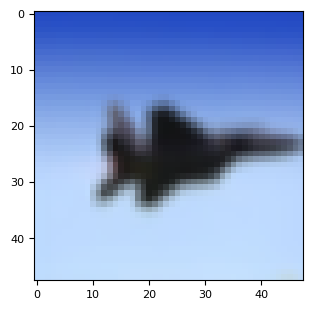

In [6]:
plt.imshow(batch[0][0].permute(1, 2, 0))

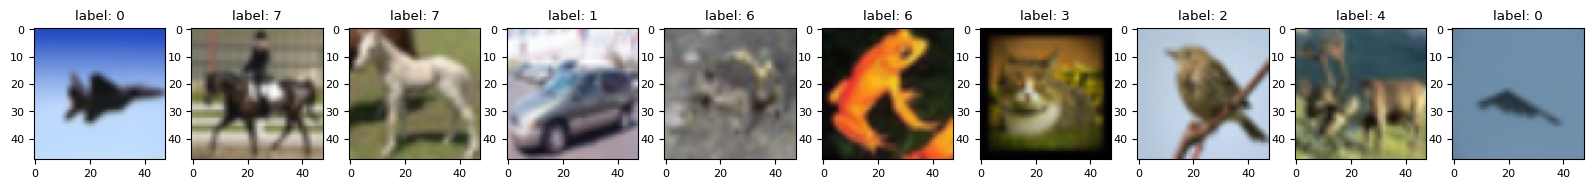

In [7]:
plt.figure(figsize=(20, 6))
for i in range(10):
    plt.subplot(1,10,i+1)
    plt.imshow(batch[0][i].permute(1, 2, 0))
    plt.title(f'label: {batch[1][i]}')
plt.show()

## **Load VGG16 model**

In [8]:
import torchvision
vgg16 = torchvision.models.vgg16(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 229MB/s]


In [9]:
p(vgg16,'cr')
p(vgg16.features,'cr')
vgg16_f = vgg16.features

Type: <class 'torchvision.models.vgg.VGG'>
Values: VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPo

In [14]:
## 모델 전체 ##
summary(vgg16, input_size=(16, 3, 48, 48))

Layer (type:depth-idx)                   Output Shape              Param #
VGG                                      [16, 1000]                --
├─Sequential: 1-1                        [16, 512, 1, 1]           --
│    └─Conv2d: 2-1                       [16, 64, 48, 48]          1,792
│    └─ReLU: 2-2                         [16, 64, 48, 48]          --
│    └─Conv2d: 2-3                       [16, 64, 48, 48]          36,928
│    └─ReLU: 2-4                         [16, 64, 48, 48]          --
│    └─MaxPool2d: 2-5                    [16, 64, 24, 24]          --
│    └─Conv2d: 2-6                       [16, 128, 24, 24]         73,856
│    └─ReLU: 2-7                         [16, 128, 24, 24]         --
│    └─Conv2d: 2-8                       [16, 128, 24, 24]         147,584
│    └─ReLU: 2-9                         [16, 128, 24, 24]         --
│    └─MaxPool2d: 2-10                   [16, 128, 12, 12]         --
│    └─Conv2d: 2-11                      [16, 256, 12, 12]         29

In [15]:
## 모델 features part ##
summary(vgg16_f, input_size=(16, 3, 48, 48))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [16, 512, 1, 1]           --
├─Conv2d: 1-1                            [16, 64, 48, 48]          1,792
├─ReLU: 1-2                              [16, 64, 48, 48]          --
├─Conv2d: 1-3                            [16, 64, 48, 48]          36,928
├─ReLU: 1-4                              [16, 64, 48, 48]          --
├─MaxPool2d: 1-5                         [16, 64, 24, 24]          --
├─Conv2d: 1-6                            [16, 128, 24, 24]         73,856
├─ReLU: 1-7                              [16, 128, 24, 24]         --
├─Conv2d: 1-8                            [16, 128, 24, 24]         147,584
├─ReLU: 1-9                              [16, 128, 24, 24]         --
├─MaxPool2d: 1-10                        [16, 128, 12, 12]         --
├─Conv2d: 1-11                           [16, 256, 12, 12]         295,168
├─ReLU: 1-12                             [16, 256, 12, 12]      

### **마지막 `conv block`만 남기고 나머지는 전부 freeze**
- ### 마지막 conv block이 fine tuning 됨

In [16]:
vgg16_f = vgg16.features
for i, child in enumerate(vgg16_f.children()):
  if i < len(vgg16_f) - 7:
    # Freeze the layers except the last 7 layers
    print(f"Freeze:[{i}]",child)
    for param in child.parameters():
      param.requires_grad = False
  else :
    print(f"Trainable:[{i}]",child)

Freeze:[0] Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
Freeze:[1] ReLU(inplace=True)
Freeze:[2] Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
Freeze:[3] ReLU(inplace=True)
Freeze:[4] MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
Freeze:[5] Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
Freeze:[6] ReLU(inplace=True)
Freeze:[7] Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
Freeze:[8] ReLU(inplace=True)
Freeze:[9] MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
Freeze:[10] Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
Freeze:[11] ReLU(inplace=True)
Freeze:[12] Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
Freeze:[13] ReLU(inplace=True)
Freeze:[14] Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
Freeze:[15] ReLU(inplace=True)
Freeze:[16] MaxPool2d(kernel_size=2, stride=2, padding=0, dilatio

In [17]:
for child in vgg16_f.children():
    for param in child.parameters():
        print(child, param.requires_grad)
        break

Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) False
Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) False
Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) False
Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) False
Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) False
Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) False
Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) False
Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) False
Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) False
Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) False
Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) True
Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) True
Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) True


In [18]:
summary(vgg16_f, input_size=(16, 3, 48, 48))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [16, 512, 1, 1]           --
├─Conv2d: 1-1                            [16, 64, 48, 48]          (1,792)
├─ReLU: 1-2                              [16, 64, 48, 48]          --
├─Conv2d: 1-3                            [16, 64, 48, 48]          (36,928)
├─ReLU: 1-4                              [16, 64, 48, 48]          --
├─MaxPool2d: 1-5                         [16, 64, 24, 24]          --
├─Conv2d: 1-6                            [16, 128, 24, 24]         (73,856)
├─ReLU: 1-7                              [16, 128, 24, 24]         --
├─Conv2d: 1-8                            [16, 128, 24, 24]         (147,584)
├─ReLU: 1-9                              [16, 128, 24, 24]         --
├─MaxPool2d: 1-10                        [16, 128, 12, 12]         --
├─Conv2d: 1-11                           [16, 256, 12, 12]         (295,168)
├─ReLU: 1-12                             [16, 256, 12,

### Layer 추가 하기
*VGG 결과를 받아 Flatten + BN + ReLU + Linear를 추가하여 classification model 완성**
- ***batch normalizatin을 필히 사용할 것***

In [19]:
class VGGFineTune(L.LightningModule):
    def __init__(self, vggnet, num_classes=10):
        super(VGGFineTune, self).__init__()
        self.features = vggnet
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.2), ##
            nn.Linear(512, num_classes) )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = F.cross_entropy(y_pred, y)
        acc = FM.accuracy(y_pred, y, task="multiclass",num_classes=10)
        metrics={'loss':loss, 'acc':acc}
        self.log_dict(metrics,prog_bar=True,on_step=False,on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = F.cross_entropy(y_pred, y)
        acc = FM.accuracy(y_pred, y, task="multiclass",num_classes=10)
        metrics = {'val_loss':loss, 'val_acc':acc}
        self.log_dict(metrics,prog_bar=True,on_step=False,on_epoch=True)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.0001)

In [20]:
vggFineTune = VGGFineTune(vgg16_f, 10)
summary(vggFineTune, input_size=(batch_size, 3, 48, 48))

Layer (type:depth-idx)                   Output Shape              Param #
VGGFineTune                              [256, 10]                 --
├─Sequential: 1-1                        [256, 512, 1, 1]          --
│    └─Conv2d: 2-1                       [256, 64, 48, 48]         (1,792)
│    └─ReLU: 2-2                         [256, 64, 48, 48]         --
│    └─Conv2d: 2-3                       [256, 64, 48, 48]         (36,928)
│    └─ReLU: 2-4                         [256, 64, 48, 48]         --
│    └─MaxPool2d: 2-5                    [256, 64, 24, 24]         --
│    └─Conv2d: 2-6                       [256, 128, 24, 24]        (73,856)
│    └─ReLU: 2-7                         [256, 128, 24, 24]        --
│    └─Conv2d: 2-8                       [256, 128, 24, 24]        (147,584)
│    └─ReLU: 2-9                         [256, 128, 24, 24]        --
│    └─MaxPool2d: 2-10                   [256, 128, 12, 12]        --
│    └─Conv2d: 2-11                      [256, 256, 12, 12]  

## **Training**

In [21]:
%%time
vggFineTune = VGGFineTune(vgg16_f, 10)
model_name="VGGNetFineTune"
epochs=10
logger = CSVLogger("logs", name=model_name)
trainer = Trainer(max_epochs=epochs, logger=logger,
                  limit_train_batches=0.5,)
trainer.fit(vggFineTune, trainloader, val_dataloaders=testloader)
# Wall time: 55.5 s

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: You are using a CUDA device ('NVIDIA L4') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'hi

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=10` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


CPU times: user 41.1 s, sys: 7.77 s, total: 48.9 s
Wall time: 56.9 s


Wall time: 2min 1s

In [24]:
v_num = logger.version
history = pd.read_csv(f'./logs/{model_name}/version_{v_num}/metrics.csv')

## **Plot**

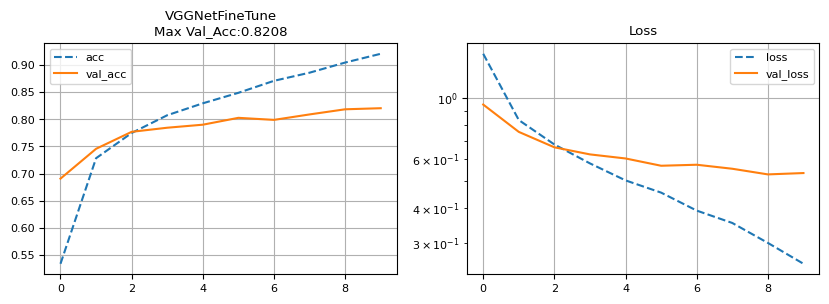

In [25]:
h1 = history.drop('step', axis=1).groupby('epoch').last()
max_ = h1['val_acc'].max()

plt.figure(figsize=(10,3))
title = model_name
plt.subplot(121)
plt.title(f"{title}\nMax Val_Acc:{max_:.4f}")
plt.plot(h1['acc'],'--', label='acc')
plt.plot(h1['val_acc'], label='val_acc')
#plt.ylim(0.7, 1)
plt.legend()
plt.grid()

plt.subplot(122)
plt.title("Loss")
plt.plot(h1['loss'],'--', label='loss')
plt.plot(h1['val_loss'], label='val_loss')
plt.semilogy()
plt.legend()
plt.grid()
plt.show()

**limit_train_batches=0.5**  
**lr=0.0001**  
val_acc : 0.8241


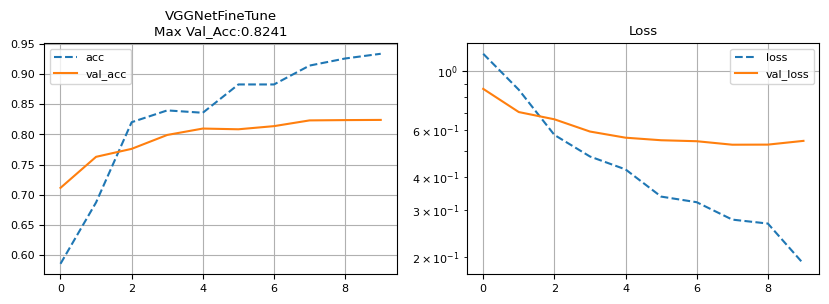

> ### **과제 3.1 LeNet-like 모델 학습 곡선과 비교**

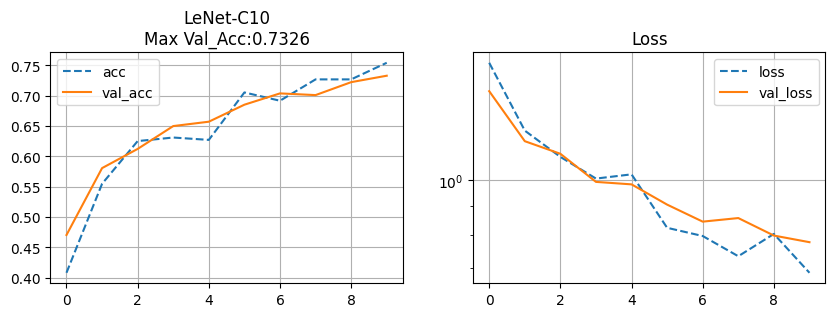

## **Prediction result with test image**

In [26]:
imgs, labels = next(iter(testloader))
ps(imgs)
ps(labels)

[] Shapetorch.Size([256, 3, 48, 48])
[] Shapetorch.Size([256])


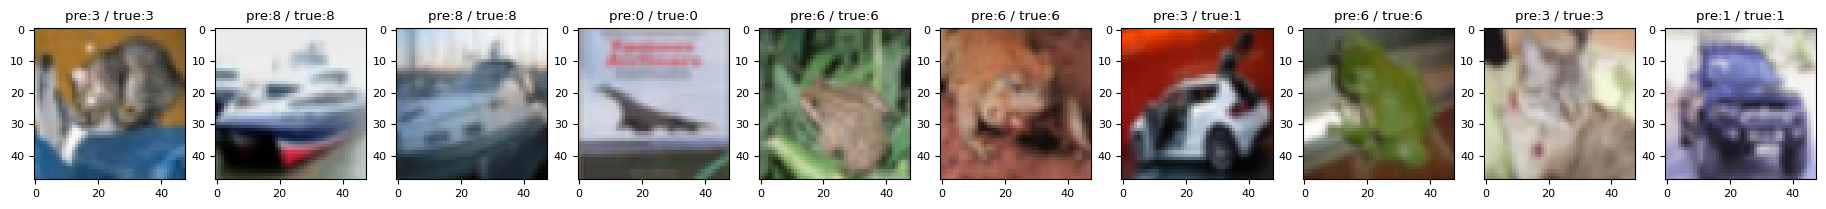

In [27]:
n_index = 0
n_plot = 10

plt.figure(figsize=(2.3*n_plot, n_plot))
vggFineTune.eval() # evaluation mode
for i in range(n_plot):
    img_idx = n_index+i
    predict = vggFineTune(imgs[img_idx].unsqueeze(dim=0)).cpu().detach().numpy()
    img = imgs[img_idx].permute(1, 2, 0)
    plt.subplot(1,n_plot,i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f'pre:{np.argmax(predict)} / true:{labels[img_idx]}')

plt.show()

## 실습과제   
### 5th conv block에서 마지막 conv, relu, maxpooling layer를 제외하고 모델을 구성해 보자  
### Freeze할 layer를 결정하자   
### 적절한 classifier를 추가하여 모델을 완성하고 학습하여 성능을 검토해 보자  

In [ ]:
vgg16_f_19 = vgg16.features[:28]
vgg16_f_19